In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.optimize import minimize 
import warnings

warnings.filterwarnings('ignore')
np.random.seed(42)

True mixture parameters:
  Component 1: weight=0.30, μ=-2.0, σ=0.8
  Component 2: weight=0.50, μ=1.0, σ=1.2
  Component 3: weight=0.20, μ=4.0, σ=0.6


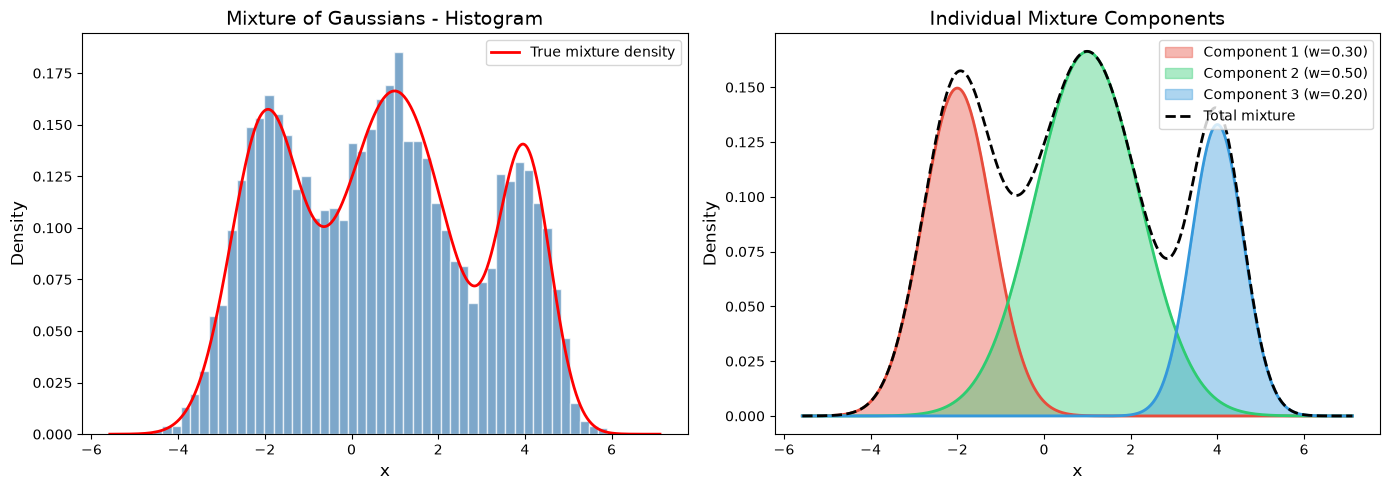

In [ ]:
# simulate data from a known mixture
def sample_gaussian_mixture(n_samples, weights, means, stds):
    weights = np.array(weights)
    K = len(weights)
   
    # Assign each sample to a component
    component_labels = np.random.choice(K, size=n_samples, p=weights)
   
    # Sample from the assigned component
    samples = np.array([
        np.random.normal(means[c], stds[c])
        for c in component_labels
    ])
   
    return samples, component_labels


# True mixture parameters
TRUE_WEIGHTS = [0.3, 0.5, 0.2]  # 3 components
TRUE_MEANS = [-2.0, 1.0, 4.0]
TRUE_STDS = [0.8, 1.2, 0.6]

n_samples = 5000
data, labels = sample_gaussian_mixture(n_samples, TRUE_WEIGHTS, TRUE_MEANS, TRUE_STDS)

print("True mixture parameters:")
for k in range(len(TRUE_WEIGHTS)):
    print(f"  Component {k+1}: weight={TRUE_WEIGHTS[k]:.2f}, μ={TRUE_MEANS[k]:.1f}, σ={TRUE_STDS[k]:.1f}")

# Visualize the data
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram with true density overlay
x_grid = np.linspace(data.min() - 1, data.max() + 1, 500)
true_density = sum(
    w * stats.norm.pdf(x_grid, m, s)
    for w, m, s in zip(TRUE_WEIGHTS, TRUE_MEANS, TRUE_STDS)
)

axes[0].hist(data, bins=50, density=True, alpha=0.7, color='steelblue', edgecolor='white')
axes[0].plot(x_grid, true_density, 'r-', linewidth=2, label='True mixture density')
axes[0].set_xlabel('x', fontsize=12)
axes[0].set_ylabel('Density', fontsize=12)
axes[0].set_title('Mixture of Gaussians - Histogram', fontsize=14)
axes[0].legend()

# Individual components
colors = ['#e74c3c', '#2ecc71', '#3498db']
for k in range(len(TRUE_WEIGHTS)):
    component_density = TRUE_WEIGHTS[k] * stats.norm.pdf(x_grid, TRUE_MEANS[k], TRUE_STDS[k])
    axes[1].fill_between(x_grid, component_density, alpha=0.4, color=colors[k],
                          label=f'Component {k+1} (w={TRUE_WEIGHTS[k]:.2f})')
    axes[1].plot(x_grid, component_density, color=colors[k], linewidth=2)

axes[1].plot(x_grid, true_density, 'k--', linewidth=2, label='Total mixture')
axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('Individual Mixture Components', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()

## Bin the data

In [ ]:
# discretization
def create_bins(data, n_bins=30):
    # creating histogram bins and compute bin counts/centers
    counts, bin_edges = np.histogram(data, bins=n_bins)
    bin_centers = (bin_edges[:-1] + bin_edges[1:])/2
    bin_width = bin_edges[1] - bin_edges[0]

    # noramlize to get empirical probabilities
    bin_probs = counts/counts.sum()

    return bin_centers, bin_probs, bin_width, bin_edges

n_bins = 40
bin_centers, bin_probs, bin_width, bin_edges = create_bins(data, n_bins)
print(f"Number of bins: {n_bins}")
print(f"Bin width: {bin_width}")

Number of bins: 40
Bin width: 0.2673561549332719


- we do this binning for computational efficiency; we work with 40 bins instead of 5000 points, noise reduction; which smooths out individual sample noise, but the tradeoff is that with binning we might lose information

## Inference Method 1: Least Squares on Binned Data
We fit mixture weights by minimizing the squared difference between observed
bin probabilities and theoretical bin probabilities

Given binned data, can we recover the mixing weights $w_k$?

For each bin $i$, we can compute the theoritical propbability that a point in it:
$${\text{bin}_i} = \sum_{k=1}^{K} w_k \cdot \left[\Phi\left(\frac{b_{i+1} -\mu_k}{\sigma_k}\right) - \Phi\left(\frac{b_i-\mu_k}{\sigma_k}\right)\right]$$

where $\Phi$ is the CDF of the standard normal

In [5]:
def mixture_bin_probs(weights, means, stds, bin_edges):
    # compute theoritical bin probabilities for a Gaussian mixture
    K = len(weights)
    n_bins = len(bin_edges)-1
    probs = np.zeros(n_bins)

    for k in range(K):
        for i in range(n_bins):
            #probability mass in bin i from component k
            prob_k = stats.norm.cdf(bin_edges[i+1], means[k], stds[k])-stats.norm.cdf(bin_edges[i], means[k], stds[k]) 
            probs[i] += weights[k]*prob_k
    return probs

def loss_function(weights_raw, means, stds, bin_edges, observed_probs):
    # softmax to ensure weights sum to 1 and are positive
    # squared error loss for weight inference
    weights = np.exp(weights_raw)/np.exp(weights_raw).sum()
    predicted_probs = mixture_bin_probs(weights, means, stds, bin_edges)

    return np.sum((observed_probs - predicted_probs)**2)

# Assuming that we know the means and stds, we infer only the weights
# (In practice, we might use EM to jointly estimate all parameters)

K = 3
initial_weights_raw = np.zeros(K)

result = minimize(loss_function, initial_weights_raw, args=(TRUE_MEANS, TRUE_STDS, bin_edges, bin_probs), method='BFGS')

# converting back from raw to normalized weights
inferred_weights_ls = np.exp(result.x)/np.exp(result.x).sum()

print("Least Squares Inference")
print(f"True weights: {TRUE_WEIGHTS}")
print(f"Inferred weights:[{','.join([f'{w:.3f}' for w in inferred_weights_ls])}]")




Least Squares Inference
True weights: [0.3, 0.5, 0.2]
Inferred weights:[0.308,0.495,0.196]


### Inference Method 2: EM ALGORITHM on Binned Data

We want to estimate **all** parameters (weights, means, stds) but we don't know which component genrated each data point:
- E-step(Expectation) : "soft" assignment, we compute the responsability : the probability that component k genrated bin center x:

$$\gamma_{ik} = \frac{w_k \cdot \mathcal{N}(x_i \mid \mu_k, \sigma_k)}{\sum_{j=1}^{K} w_j \cdot \mathcal{N}(x_i \mid \mu_j, \sigma_j)}$$

Points near $\mu$ get high responsibility for component k


- M-Step(Maximization): Update Parameter; using the soft assignments, compute weighted estimates:
1. effective count for component k : $$N_k = \sum_i n_i\cdot \gamma_{ik}$$
2. New weight : $$w_k^{new} = \frac{N_k}{N}$$
3. Weighted mean : $$\mu_k{new} = \frac{\sum_i n_i \gamma_{ik} x_i}{N_k}$$
4. Weighted std : $$ \sigma_k^{new} = \sqrt{\frac{\sum_i n_i \gamma_{ik} (x_i - \mu_k^{new})^2}{N_k}}$$

In [9]:
def em_binned(bin_centers, bin_counts,K, n_iter=100, tol=1e-6):
    # this algorithm would estimate weights, means and standard deviation
    np.random.seed(123)
    weights = np.ones(K)/K
    means = np.random.choice(bin_centers, K, replace= False)
    stds = np.ones(K)*np.std(bin_centers)

    total_counts = bin_counts.sum()

    for iteration in range(n_iter):
        # compute responsibilities for each bin
        # gamma[i,k] = responsibility of component k for bin i
        gamma = np.zeros((len(bin_centers), K))
        for i, x in enumerate(bin_centers):
            for k in range(K):
                gamma[i,k] = weights[k]*stats.norm.pdf(x,means[k], stds[k])
            if gamma[i].sum()>0:
                gamma[i] /= gamma[i].sum()

        # weight responsabilities by bin counts 
        weighted_gamma = gamma*bin_counts[:, np.newaxis]

        # M-step : update parameters
        Nk = weighted_gamma.sum(axis=0)
        weights_new = Nk/total_counts

        means_new = np.zeros(K)
        stds_new = np.zeros(K)

        for k in range(K):
            if Nk[k]>0:
                means_new[k] = np.sum(weighted_gamma[:,k]*bin_centers)/Nk[k]
                variance = np.sum(weighted_gamma[:,k]* (bin_centers-means_new[k])**2)/Nk[k]
                stds_new[k] = np.sqrt(max(variance,0.01)) # floor to precent collapse

        #check convergence
        if np.allclose(weights, weights_new, atol=tol) and np.allclose(means, means_new, atol=tol):
            print(f"EM converged at iteration {iteration + 1}")
            break
        weights, means, stds = weights_new, means_new, stds_new
    # sort by means for consistent comparison
    order = np.argsort(means)
    return weights[order], means[order], stds[order]

bin_counts,_ = np.histogram(data, bins=n_bins)
bin_counts = bin_counts.astype(float)

inferred_weights_em, inferred_means_em, inferred_stds_em = em_binned(bin_centers, bin_counts, K=3, n_iter =200)

print(" EM ALOGRITHM INFERENCE")
print(f"{'Parmeter':<12}{'True':<25}{'Inferred':<25}")
print('-'*60)
print(f"{'Weights':<12}{str(TRUE_WEIGHTS):<25}{str([f'{w:.3f}'for w in inferred_weights_em]):<25}")
print(f"{'Means':<12}{str(TRUE_MEANS):<25}{str([f'{m:.3f}'for m in inferred_means_em]):<25}")
print(f"{'Stds':<12}{str(TRUE_STDS):<25}{str([f'{s:.3f}'for s in inferred_stds_em]):<25}")

 EM ALOGRITHM INFERENCE
Parmeter    True                     Inferred                 
------------------------------------------------------------
Weights     [0.3, 0.5, 0.2]          ['0.314', '0.482', '0.204']
Means       [-2.0, 1.0, 4.0]         ['-1.967', '0.973', '3.982']
Stds        [0.8, 1.2, 0.6]          ['0.812', '1.154', '0.613']


## Comparing all results

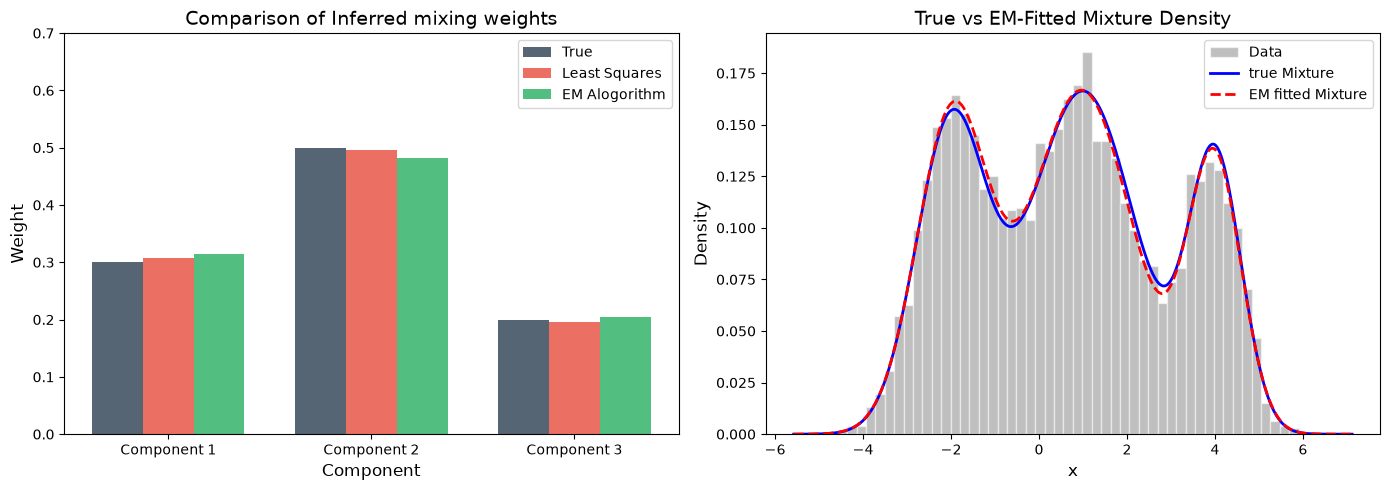

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14,5))

x_pos = np.arange(3)
width = 0.25

axes[0].bar(x_pos-width, TRUE_WEIGHTS, width, label='True', color='#2c3e50', alpha=0.8)
axes[0].bar(x_pos, inferred_weights_ls, width, label='Least Squares', color='#e74c3c', alpha=0.8)
axes[0].bar(x_pos+width, inferred_weights_em, width, label='EM Alogorithm', color='#27ae60', alpha=0.8)

axes[0].set_xlabel('Component', fontsize=12)
axes[0].set_ylabel('Weight', fontsize=12)
axes[0].set_title('Comparison of Inferred mixing weights', fontsize=14)
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(['Component 1', 'Component 2', 'Component 3'])
axes[0].legend()
axes[0].set_ylim(0,0.7)

# density comparison
x_grid = np.linspace(data.min()-1, data.max()+1, 500)
true_density = sum(w*stats.norm.pdf(x_grid,m,s) for w,m,s in zip(TRUE_WEIGHTS, TRUE_MEANS, TRUE_STDS))
em_density = sum(w*stats.norm.pdf(x_grid,m,s) for w,m,s in zip(inferred_weights_em, inferred_means_em, inferred_stds_em))

axes[1].hist(data, bins=50, density=True, alpha=0.5, color='gray', edgecolor='white', label='Data')
axes[1].plot(x_grid, true_density, 'b-', linewidth=2, label='true Mixture')
axes[1].plot(x_grid, em_density, 'r--', linewidth=2, label='EM fitted Mixture')

axes[1].set_xlabel('x', fontsize=12)
axes[1].set_ylabel('Density', fontsize=12)
axes[1].set_title('True vs EM-Fitted Mixture Density', fontsize=14)
axes[1].legend()

plt.tight_layout()
plt.show()



In [12]:
# Quantitative Comparison
print("Inference Error Summary")
weight_error_ls = np.sqrt(np.mean((np.array(TRUE_WEIGHTS) - inferred_weights_ls)**2))
weight_error_em = np.sqrt(np.mean((np.array(TRUE_WEIGHTS) - inferred_weights_em)**2))

print(f"Weight RMSE (LEAST SQUARES): {weight_error_ls:.4f}")
print(f"Weight RMSE (EM ALGORITHM): {weight_error_em:.4f}")

Inference Error Summary
Weight RMSE (LEAST SQUARES): 0.0058
Weight RMSE (EM ALGORITHM): 0.0137
